# Hard Istance Max Cut with different annealing methods

#### Imports

In [38]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from src.annealing_utils import get_driver_hamiltonian,get_longitudinal_hamiltonian,computational_basis
from src.schedule_utils import SchedulerModel,Schedule

ModuleNotFoundError: No module named 'src.fermi_hubbard_library'

## Initialization of the target Hamiltonian

#### Hyperapameters

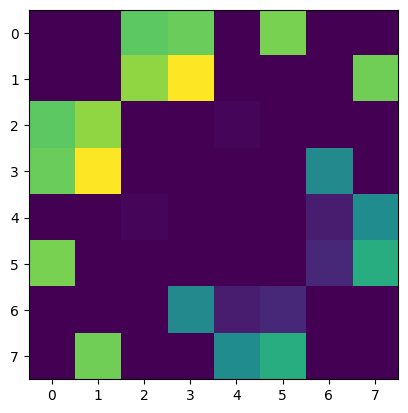

In [30]:
#### create istances on networkx
nqubits = 8

basis=computational_basis(nqubits)
graph_instance = nx.random_regular_graph(d=3, n=8)

# Assign random weights in [0,1]
for u, v in graph_instance.edges():
    graph_instance[u][v]['weight'] = np.random.uniform(0, 1)
    
jij = nx.to_numpy_array(graph_instance)  # unweighted adjacency matrix

plt.imshow(jij)
plt.show()

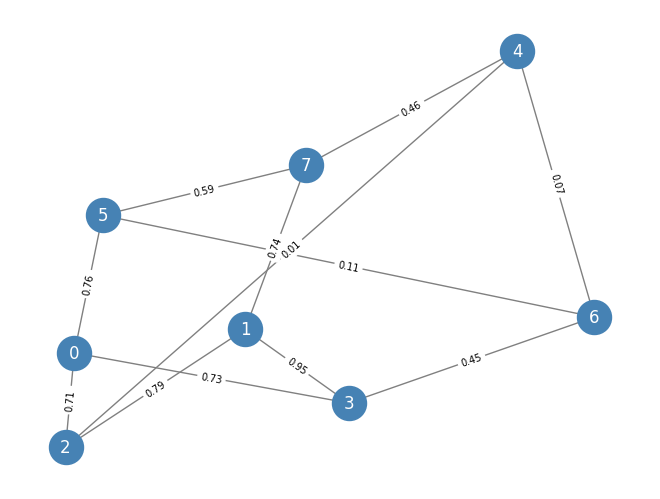

In [31]:

pos = nx.spring_layout(graph_instance, seed=42)
nx.draw(graph_instance, pos, with_labels=True, node_color='steelblue',
        edge_color='gray', node_size=600, font_color='white')

# draw edge weights
edge_labels = {(u,v): f"{graph_instance[u][v]['weight']:.2f}" for u,v in graph_instance.edges()}
nx.draw_networkx_edge_labels(graph_instance, pos, edge_labels=edge_labels, font_size=7)

plt.show()

#### Hamiltonian Initialization

In [32]:
nqubits=jij.shape[0]

target_hamiltonian=get_longitudinal_hamiltonian(jij)
driver_hamiltonian=get_driver_hamiltonian(nqubits=nqubits)



#### Analysis of the spectrum of the target hamiltonian

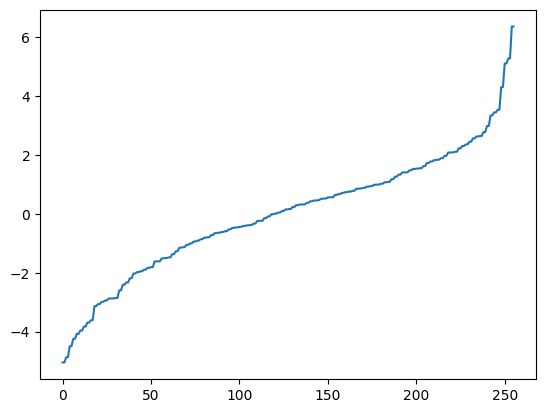

(-5.047567476114747+0j) (-4.867803445312404+0j) [0 0 1 1 0 1 0 1] [1 1 0 0 0 0 1 1]


In [35]:
values=target_hamiltonian.diagonal()

spectrum_target_hamiltonian=np.sort(values)
eigenstates_target_hamiltonian=basis[np.argsort(values)]

plt.plot(spectrum_target_hamiltonian)
plt.show()

print(spectrum_target_hamiltonian[0],spectrum_target_hamiltonian[2],eigenstates_target_hamiltonian[0],eigenstates_target_hamiltonian[2])

#### Time evolution

In [36]:
from scipy.sparse.linalg import eigsh,expm_multiply
# initialize the state
_,psi=eigsh(driver_hamiltonian,which='SA',k=1)
psi_init=psi[:,0]

# nlevels and time evolution
nlevels=4
tau=10
time_steps=int(10*tau)
time=np.linspace(0,tau,time_steps)
delta_t=time[1]-time[0]

# initialization
spectrum=np.zeros((time_steps,nlevels))
energy=np.zeros(time_steps)

psi=psi_init
for i,t in enumerate(time):
    
    hamiltonian_t=(1-t/tau)*driver_hamiltonian+target_hamiltonian*t/tau
    psi=expm_multiply(-1j*delta_t*hamiltonian_t,psi)
    spectrum_t,_=eigsh(hamiltonian_t,which='SA',k=nlevels)
    spectrum[i]=np.sort(spectrum_t)
    energy[i]=psi.conj().dot(hamiltonian_t.dot(psi))
    
    

/tmp/ipykernel_54598/1108131275.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  energy[i]=psi.conj().dot(hamiltonian_t.dot(psi))


Check the results

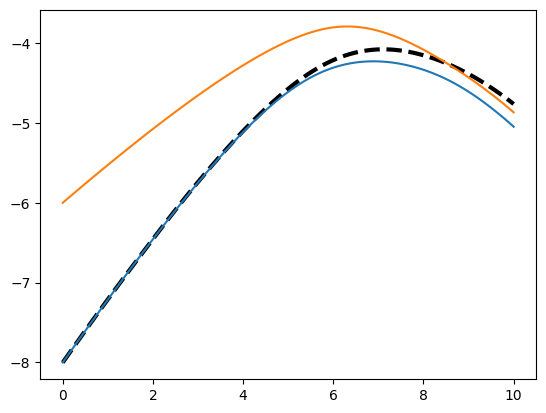

In [37]:

plt.plot(time,energy,color='black',linestyle='--',linewidth=3)
for i in range(spectrum.shape[1]):
    if i%2==0:
        plt.plot(time,spectrum[:,i])

plt.show()

## Optimal Control Method

In [ ]:
model=SchedulerModel(initial_state=psi_configuration,target_hamiltonian=PPoperator.hamiltonian,initial_hamiltonian=InitialHamiltonian.hamiltonian,second_target_hamiltonian=QQoperator.hamiltonian,mean_field_target_hamiltonain=MeanFieldHamiltonian.hamiltonian,tf=tf,nsteps=nsteps,number_of_parameters=number_of_parameters,type='F-CRAB',seed=42,reference_hamiltonian=TargetHamiltonian.hamiltonian,mode='annealing ansatz',J2operator=J2pshell)

if args.load:
    data=np.load(args.load_filename,allow_pickle=True)
    load_parameters=data['history_parameters'][-1]
    model.load(parameters=load_parameters)


res = minimize(
                    model.forward,
                    model.parameters,
                    method='L-BFGS-B',
                    tol=10**-6,
                    callback=model.callback,
                    options=None,
                    
                )

model.parameters = res.x
energy = model.forward(model.parameters)